<a href="https://colab.research.google.com/github/Sakti-Cristopel/Dasar-Python/blob/main/Pertemuan7_Sakti%20Cristopel%20Lingga_2404010125.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pertemuan 7 - Regresi Linear
Nama : Sakticristopel Lingga
NIM : [2404010125]



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 300

pengalaman = np.random.uniform(0, 20, n)

edu = np.random.choice(
    [0,1,2],
    n
)

kota = np.random.choice(
    ['Jakarta','Surabaya','Bandung'],
    n
)

gaji = (
    3.0
    + 2.2 * pengalaman
    + 1.5 * edu
    + np.where(kota=='Jakarta',4.0,0)
    + np.random.normal(0,2,n)
)

df = pd.DataFrame({
    'pengalaman':pengalaman,
    'edu':edu,
    'kota':kota,
    'gaji':gaji
})

print("Shape :", df.shape)
print(df.describe().round(2))

df.head()

Shape : (300, 4)
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


,pengalaman,edu,kota,gaji
0,7.490802,0,Jakarta,21.953247
1,19.014286,1,Jakarta,46.721665
2,14.639879,2,Surabaya,34.952649
3,11.973170,2,Bandung,32.437143
4,3.120373,2,Jakarta,17.384265


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.get_dummies(
    df,
    columns=['kota'],
    drop_first=True,
    dtype=int
)

print(df.columns.tolist())

X = df.drop('gaji', axis=1)
y = df['gaji']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(
    f"Train: {X_train.shape[0]} baris"
)

print(
    f"Test: {X_test.shape[0]} baris"
)

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)

X_test_s = scaler.transform(X_test)

['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train: 240 baris
Test: 60 baris


In [3]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_s, y_train)

print(f"β0 (Intercept) : {model.intercept_:.3f}")

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_.round(3)
})

coef_df = coef_df.sort_values(
    'Koefisien',
    ascending=False
)

print(coef_df.to_string(index=False))

β0 (Intercept) : 27.514
        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


In [4]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_pred = model.predict(X_test_s)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("=== Metrik Evaluasi ===")

print(
    f"MAE = {mae:.3f} juta rupiah"
)

print(
    f"RMSE = {rmse:.3f} juta rupiah"
)

print(
    f"R² = {r2:.4f}"
)

print(
    f"Variasi dijelaskan = {r2*100:.1f}%"
)

print(
    f"Selisih RMSE-MAE = {(rmse-mae):.3f}"
)

=== Metrik Evaluasi ===
MAE = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R² = 0.9740
Variasi dijelaskan = 97.4%
Selisih RMSE-MAE = 0.474


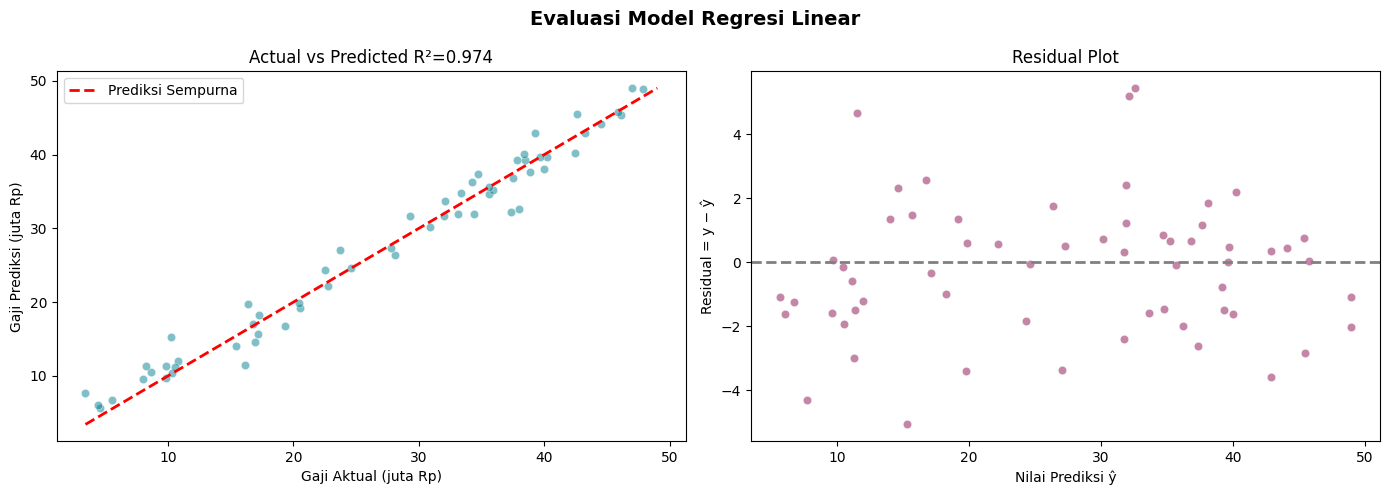

In [5]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

# Actual vs Predicted

axes[0].scatter(
    y_test,
    y_pred,
    alpha=0.5,
    color='#028090',
    edgecolors='white',
    lw=0.5
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

axes[0].plot(
    lims,
    lims,
    'r--',
    lw=2,
    label='Prediksi Sempurna'
)

axes[0].set_xlabel(
    'Gaji Aktual (juta Rp)'
)

axes[0].set_ylabel(
    'Gaji Prediksi (juta Rp)'
)

axes[0].set_title(
    f'Actual vs Predicted R²={r2:.3f}'
)

axes[0].legend()

# Residual Plot

residuals = y_test - y_pred

axes[1].scatter(
    y_pred,
    residuals,
    alpha=0.5,
    color='#880E4F',
    edgecolors='white',
    lw=0.5
)

axes[1].axhline(
    0,
    color='gray',
    linestyle='--',
    lw=2
)

axes[1].set_xlabel(
    'Nilai Prediksi ŷ'
)

axes[1].set_ylabel(
    'Residual = y − ŷ'
)

axes[1].set_title(
    'Residual Plot'
)

plt.suptitle(
    'Evaluasi Model Regresi Linear',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    'evaluasi_regresi.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

Pada praktikum ini dilakukan pembangunan model regresi linear untuk memprediksi gaji berdasarkan pengalaman kerja, tingkat pendidikan, dan kota kerja. Tahapan meliputi pembuatan dataset sintetis, preprocessing menggunakan One-Hot Encoding dan StandardScaler, pelatihan model, evaluasi menggunakan MAE, RMSE, dan R², serta visualisasi hasil prediksi. Hasil menunjukkan bahwa model mampu menjelaskan sebagian besar variasi data dengan tingkat kesalahan yang relatif kecil sehingga regresi linear dapat digunakan sebagai pendekatan awal dalam prediksi gaji.